In [ ]:
#| default_exp models.arima

In [ ]:
#| export
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
from xml.parsers.expat import model
from sklearn.base import clone
from tabnanny import verbose
import numpy as np
import pandas as pd
import copy
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform,
                                      rolling_quantile, rolling_mean, rolling_std,
                        expanding_mean, expanding_std, expanding_quantile)
from peshbeen.helpers import seasonal_diff, undiff_ts, invert_seasonal_diff
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
from peshbeen.formatting import make_main_gt, gt_mini, inject_header_table_groups, cov_table, make_var_gt_regimes
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")
import copy
import statsmodels.api as sm
from scipy.stats import norm, multivariate_normal
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.special import logsumexp
from scipy.stats import t
import re # for regex escaping to build drop patterns
from statsforecast.models import AutoARIMA, ARIMA
import warnings
warnings.filterwarnings("ignore")


class arima:

    def __init__(
        self,
        target_col: str,
        order: Optional[Tuple[int, int, int]] = (0, 0, 0),
        seasonal_order: Optional[Tuple[int, int, int]] = (0, 0, 0),
        seasonal_length: Optional[int] = 1,
        lag_transform: Optional[list] = None,
        trend: Optional[str] = None,
        pol_degree: int = 1,
        ets_params: Optional[tuple] = None,
        change_points: Optional[List[int]] = None,
        box_cox: bool = False,
        box_cox_lmda: Optional[float] = None,
        box_cox_biasadj: bool = False,
        cat_variables: Optional[List[str]] = None,
        target_encode: bool = False) -> None:

        """
        Initialize the arima model with the specified parameters and configurations.

        Parameters
        ----------
        target_col : str
            Name of the target variable column in the input DataFrame.
        order : tuple of int, optional
            The (p, d, q) order of the ARIMA model. Default is (0, 0, 0).
        seasonal_order : tuple of int, optional
            The (P, D, Q) order of the seasonal ARIMA model. Default is (0, 0, 0).
        seasonal_length : int, optional
            The seasonal period for the seasonal ARIMA model. Default is 1.
        lag_transform : list of function objects, optional
            List of lag-transform function objects to apply to the target variable (e.g. [expanding_mean(shift=1), rolling_std(window_size=3, shift=1)]). Each function should take a pandas Series as input and return a Series of the same length. Default is None (no lag transforms).
        trend : str, optional
            Trend strategy to use. Options are 'linear' for linear trend removal, 'ets' for ETS-based trend removal, 'feature_lr' for using linear trend components as features, and 'feature_ets' for using ETS trend components as features. Default is None (no trend handling).
        pol_degree : int, optional
            Degree of polynomial trend to fit when using 'linear' or 'feature_lr' trend strategy. Default is 1 (linear trend).
        ets_params : tuple, optional
            Tuple of (model_params_dict, fit_params_dict) to specify the parameters for the ExponentialSmoothing model when using 'ets' or 'feature_ets' trend strategy. The first element should be a dictionary of parameters to pass to the ExponentialSmoothing constructor, and the second element should be a dictionary of parameters to pass to the fit() method. Default is None (use default ETS parameters).
        change_points : list of int, optional
            List of indices in the time series where change points occur for piecewise linear trend fitting. Only used when trend strategy is 'linear' or 'feature_lr'. Default is None (no change points, fit a single linear trend).
        box_cox : bool, optional
            Whether to apply Box-Cox transformation to the target variable before modeling. Default is False.
        box_cox_lmda : float, optional
            Lambda parameter for Box-Cox transformation. If None, lambda will be estimated from the data. Default is None.
        box_cox_biasadj : bool, optional
            Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Default is False.
        cat_variables : list of str, optional
            List of categorical feature column names. If provided, these columns will be treated as categorical variables and encoded accordingly. Default is None (no categorical variables).
        target_encode : bool, optional
            Whether to use target encoding for categorical variables instead of one-hot encoding. If True, each categorical variable will be replaced with the mean of the target variable for each category, computed using K-fold target encoding to avoid data leakage. Default is False (use one-hot encoding for categorical variables).

        Returns
        -------
        None
        """
        
        self.target_col = target_col
        self.cat_variables = cat_variables
        self.target_encode = target_encode
        self.cps = change_points
        self.pol = pol_degree
        self.box_cox = box_cox
        self.lamda = box_cox_lmda
        self.biasadj = box_cox_biasadj
        self.order = order
        self.seasonal_order = seasonal_order
        self.seasonal_length = seasonal_length
        self.lag_transform = lag_transform

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if ets_params is not None:
            self.ets_model = ets_params[0]
            self.ets_fit = ets_params[1]
        else:
            self.ets_model = None
            self.ets_fit = None

        # ── placeholders set during fit ───────────────────────────────────────
        self.tuned_params = None
        self.actuals = None
        self.prob_forecasts = None

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self,
                  df: pd.DataFrame) -> pd.DataFrame:
        """
        Prepare the data for modeling by applying the specified transformations and feature engineering steps.

        Parameters
        ----------
        df : pd.DataFrame
            Input DataFrame containing the target and any feature columns.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            if self.target_encode:
                for col in self.cat_variables:
                    encode_col = col + "_target_encoded"
                    dfc[encode_col] = kfold_target_encoder(dfc, col, self.target_col, 36)
                self.df_encode = dfc.copy()
                dfc = dfc.drop(columns=self.cat_variables)

            else:
                for col, cats in self.cat_var.items():
                    dfc[col] = pd.Categorical(dfc[col], categories=cats) # ensure same categories as training
                dfc = pd.get_dummies(dfc, dtype=float)
                for pat in self.drop_categ_patterns:
                    cols = list(dfc.filter(regex=pat).columns)
                    if cols:
                        dfc.drop(cols, axis=1, inplace=True)

        if self.target_col not in dfc.columns:
            return dfc.dropna()

        # ── Box-Cox ───────────────────────────────────────────────────────────
        if self.box_cox:
            self.is_zero = np.any(np.array(dfc[self.target_col]) < 1)
            trans_data, self.lamda = box_cox_transform(
                x=dfc[self.target_col], shift=self.is_zero, box_cox_lmda=self.lamda
            )
            dfc[self.target_col] = trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.target_orig = dfc[self.target_col].copy()

            if self.trend in ("linear", "feature_lr"):
                if self.cps is not None:
                    trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol,
                        breakpoints=self.cps, type='piecewise'
                    )
                else:
                    trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol
                    )
                if self.trend == "linear":
                    dfc[self.target_col] = dfc[self.target_col] - trend_vals

            elif self.trend in ("ets", "feature_ets"):
                self.ets_model_fit = ExponentialSmoothing(
                    dfc[self.target_col], **self.ets_model
                ).fit(**self.ets_fit)
                if self.trend == "ets":
                    dfc[self.target_col] = dfc[self.target_col] - self.ets_model_fit.fittedvalues.values

            else:
                raise ValueError(
                    f"Unknown trend type '{self.trend}'. "
                    "Use 'linear', 'ets', 'feature_lr', or 'feature_ets'."
                )

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for func in self.lag_transform:
                if isinstance(func, (expanding_std, expanding_mean)):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[self.target_col])
                elif isinstance(func, expanding_quantile):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                elif isinstance(func, rolling_quantile):
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                else:
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[self.target_col])

        # ── Trend as features ─────────────────────────────────────────────────
        if self.trend is not None:
            if self.trend == "feature_lr":
                for i in range(self.X_trend.shape[1]):
                    dfc[f"trend_{i}"] = self.X_trend[:, i]
            elif self.trend == "feature_ets":
                dfc["trend"] = self.ets_model_fit.fittedvalues.values

        return dfc.dropna()

    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
            df: pd.DataFrame
            ) -> None:
        """
        Fit the model to the training data by applying the specified data preparation steps and then fitting the ARIMA model.

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing the target and any feature columns.
        """
        # Build categorical lookup for non-native-cat models
        if self.cat_variables is not None and not self.target_encode:
            self.cat_var = {
                c: sorted(df[c].drop_duplicates().tolist())
                for c in self.cat_variables
            }
            self.drop_categ_patterns = []
            for c in self.cat_variables:
                base = sorted(df[c].drop_duplicates().tolist())[0]
                self.drop_categ_patterns.append(rf"^{re.escape(c)}_{re.escape(str(base))}$")

        model_df = self.data_prep(df)
        self.X = model_df.drop(columns=[self.target_col]).to_numpy()
        self.y = model_df[self.target_col].to_numpy()

        self.model = ARIMA(order=self.order, seasonal_order=self.seasonal_order, season_length= self.seasonal_length)
        if self.cat_variables is not None or self.lag_transform is not None:
            self.model.fit(self.y, self.X)
        else:
            self.model.fit(self.y)

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────

    def _k(self) -> int:
        """Number of model parameters (approximate)."""
        base = self.X.shape[1]
        if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            return base + 2   # coefficients + intercept + variance
        return base + 1       # coefficients + variance

    def _ic_base(self):
        k = self._k()
        n = len(self.y)
        rss = np.sum((self.y.to_numpy() - self.model_fit.predict(self.X)) ** 2)
        return k, n, rss

    @property
    def aic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k

    @property
    def aicc(self) -> float:
        k, n, rss = self._ic_base()
        aic = n * np.log(rss / n) + 2 * k
        return aic + (2 * k * (k + 1)) / (n - k - 1)

    @property
    def bic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + k * np.log(n)

    @property
    def hqc(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k * np.log(np.log(n))

    def copy(self):
        return copy.deepcopy(self)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> np.ndarray:
        """
        Recursive multi-step forecast.

        Parameters
        ----------
        H : int
            Forecast horizon.
        exog : pd.DataFrame | None, default None
            Optional dataframe of future regressors.

        Returns
        -------
        np.ndarray
            Forecast values of length `H`.
        """
        # ── Prepare exog ──────────────────────────────────────────────────────
        if exog is not None:
            if self.cat_variables is not None:
                if self.target_encode:
                    for col in self.cat_variables:
                        encode_col = col + "_target_encoded"
                        exog[encode_col] = target_encoder_for_test(self.df_encode, exog, col)
                    exog = exog.drop(columns=self.cat_variables)
                else:
                    exog = self.data_prep(exog)

        # Rolling lag history
        lags = self.y.tolist()

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        if self.trend is not None:
            if self.trend in ("linear", "feature_lr"):
                trend_forecast, X_trend_forecast = forecast_trend(
                    model=self.lr_model, H=H, start=self.len,
                    degree=self.pol, breakpoints=self.cps
                )
            else:  # ets or feature_ets
                trend_forecast = np.array(self.ets_model_fit.forecast(H))

        # ── Recursive forecast loop ───────────────────────────────────────────

        if self.lag_transform is not None:

            ## create and empty array/matrix to to store 1Xn features for each step
            feat = np.array([]).reshape(0, self.X.shape[1])

            predictions = []
            for i in range(H):
                # Exogenous features for step i
                x_var = exog.iloc[i, :].tolist() if exog is not None else []

                # Lag-transform features
                transform_lag = []
                series_array = np.array(lags)
                for func in self.lag_transform:
                    transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

                inp = x_var + transform_lag
                df_inp = np.array(inp).reshape(1, -1)
                feat = np.vstack([feat, df_inp])
                if i == 0:
                    pred = self.model.predict(i+1, X=feat)["mean"][0]
                else:
                    pred = self.model.predict(i+1, X=feat)["mean"][-1]
                lags.append(pred)
                predictions.append(pred)

            # ── Post-processing ───────────────────────────────────────────────────
            forecasts = np.array(predictions)
        else:
            if exog is not None:
                forecasts = self.model.predict(h=H, X=exog.to_numpy())["mean"]
            else:
                forecasts = self.model.predict(h=H)["mean"]

        # Add back removed trend
        if self.trend is not None:
            if self.trend in ("linear", "ets"):
                forecasts = forecasts + trend_forecast

        # Non-negativity
        forecasts = np.array([max(0, x) for x in forecasts])

        # Invert Box-Cox
        if self.box_cox:
            forecasts = back_box_cox_transform(
                y_pred=forecasts, lmda=self.lamda,
                shift=self.is_zero, box_cox_biasadj=self.biasadj
            )

        return forecasts

    def cross_validate(self,
                       df: pd.DataFrame,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       h_split_point: Optional[int] = None,
                       cv_df: bool = False
                       ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Run cross-validation using time series splits.

        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing the target and any feature columns.
        cv_split : int
            Number of cross-validation splits.
        test_size : int
            Number of periods in each test set.
        metrics : list of callables
            List of metric functions to evaluate (e.g. [mean_absolute_error, mean_squared_error]).
        step_size : int, default 1
            Step size to move the test window forward in each split.
        h_split_point : int or None, default None
            Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done.
        cv_df : bool, default False
            Whether to return the cross-validation dataframe. If True, also returns a DataFrame with forecasts and actuals for each fold.
        Returns
        -------
        pd.DataFrame
            DataFrame containing overall performance metrics averaged across splits, and a DataFrame with predictions and true values for each split.
        """

        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}
        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test = test.drop(columns=[self.target_col])
            y_test = np.array(test[self.target_col])
            self.fit(train)
            bb_forecast = self.forecast(test_size, x_test)
            # Evaluate each metric
            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, bb_forecast, train[self.target_col])
                else:
                    eval_val = m(y_test, bb_forecast)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = bb_forecast[:h_split_point], bb_forecast[h_split_point:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_col]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_col]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)
            
            if cv_df:
                ## store results for this split
                split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                                "split": np.repeat(f"fold_{idx+1}", len(test)), "y_true": y_test, "y_pred": bb_forecast}
                cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)

        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"score_before_{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"score_after_{h_split_point}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")
        return overall_performance, cv_df_

In [ ]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import *

In [ ]:
#| echo: false
docments(arima, full=True)
DocmentTbl(arima)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| target_col | str |  | Name of the target variable column in the input DataFrame. |
| order | Optional[Tuple[int, int, int]] | (0, 0, 0) | The (p, d, q) order of the ARIMA model. Default is (0, 0, 0). |
| seasonal_order | Optional[Tuple[int, int, int]] | (0, 0, 0) | The (P, D, Q) order of the seasonal ARIMA model. Default is (0, 0, 0). |
| seasonal_length | Optional[int] | 1 | The seasonal period for the seasonal ARIMA model. Default is 1. |
| lag_transform | Optional[list] | None | List of lag-transform function objects to apply to the target variable (e.g. [expanding_mean(shift=1), rolling_std(window_size=3, shift=1)]). Each function should take a pandas Series as input and return a Series of the same length. Default is None (no lag transforms). |
| trend | Optional[str] | None | Trend strategy to use. Options are 'linear' for linear trend removal, 'ets' for ETS-based trend removal, 'feature_lr' for using linear trend components as features, and 'feature_ets' for using ETS trend components as features. Default is None (no trend handling). |
| pol_degree | int | 1 | Degree of polynomial trend to fit when using 'linear' or 'feature_lr' trend strategy. Default is 1 (linear trend). |
| ets_params | Optional[tuple] | None | Tuple of (model_params_dict, fit_params_dict) to specify the parameters for the ExponentialSmoothing model when using 'ets' or 'feature_ets' trend strategy. The first element should be a dictionary of parameters to pass to the ExponentialSmoothing constructor, and the second element should be a dictionary of parameters to pass to the fit() method. Default is None (use default ETS parameters). |
| change_points | Optional[List[int]] | None | List of indices in the time series where change points occur for piecewise linear trend fitting. Only used when trend strategy is 'linear' or 'feature_lr'. Default is None (no change points, fit a single linear trend). |
| box_cox | bool | False | Whether to apply Box-Cox transformation to the target variable before modeling. Default is False. |
| box_cox_lmda | Optional[float] | None | Lambda parameter for Box-Cox transformation. If None, lambda will be estimated from the data. Default is None. |
| box_cox_biasadj | bool | False | Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Default is False. |
| cat_variables | Optional[List[str]] | None | List of categorical feature column names. If provided, these columns will be treated as categorical variables and encoded accordingly. Default is None (no categorical variables). |
| target_encode | bool | False | Whether to use target encoding for categorical variables instead of one-hot encoding. If True, each categorical variable will be replaced with the mean of the target variable for each category, computed using K-fold target encoding to avoid data leakage. Default is False (use one-hot encoding for categorical variables). |
| **Returns** | **None** |  |  |

In [ ]:
#| echo: false
show_doc(arima.fit)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/arima.py#L224){target="_blank" style="float:right; font-size:smaller"}

### arima.fit

```python

def fit(
    df:pd.DataFrame, # Training DataFrame containing the target and any feature columns.
)->None:


```

*Fit the model to the training data by applying the specified data preparation steps and then fitting the ARIMA model.*

In [ ]:
#| echo: false
DocmentTbl(arima.fit)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| df | pd.DataFrame | Training DataFrame containing the target and any feature columns. |
| **Returns** | **None** |  |

In [ ]:
#| echo: false
show_doc(arima.forecast)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/arima.py#L301){target="_blank" style="float:right; font-size:smaller"}

### arima.forecast

```python

def forecast(
    H:int, # Forecast horizon.
    exog:Optional[pd.DataFrame]=None, # Optional dataframe of future regressors.
)->np.ndarray: # Forecast values of length `H`.


```

*Recursive multi-step forecast.*

In [ ]:
#| echo: false
DocmentTbl(arima.forecast)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| H | int |  | Forecast horizon. |
| exog | Optional[pd.DataFrame] | None | Optional dataframe of future regressors. |
| **Returns** | **np.ndarray** |  | **Forecast values of length `H`.** |

In [ ]:
#| echo: false
show_doc(arima.cross_validate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/arima.py#L398){target="_blank" style="float:right; font-size:smaller"}

### arima.cross_validate

```python

def cross_validate(
    df:pd.DataFrame, # DataFrame containing the target and any feature columns.
    cv_split:int, # Number of cross-validation splits.
    test_size:int, # Number of periods in each test set.
    metrics:List[Callable], # List of metric functions to evaluate (e.g. [mean_absolute_error, mean_squared_error]).
    step_size:int=1, # Step size to move the test window forward in each split.
    h_split_point:Optional[int]=None, # Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done.
    cv_df:bool=False, # Whether to return the cross-validation dataframe. If True, also returns a DataFrame with forecasts and actuals for each fold.
)->Tuple[pd.DataFrame, pd.DataFrame]:


```

*Run cross-validation using time series splits.*

In [ ]:
#| echo: false
DocmentTbl(arima.cross_validate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | DataFrame containing the target and any feature columns. |
| cv_split | int |  | Number of cross-validation splits. |
| test_size | int |  | Number of periods in each test set. |
| metrics | List[Callable] |  | List of metric functions to evaluate (e.g. [mean_absolute_error, mean_squared_error]). |
| step_size | int | 1 | Step size to move the test window forward in each split. |
| h_split_point | Optional[int] | None | Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done. |
| cv_df | bool | False | Whether to return the cross-validation dataframe. If True, also returns a DataFrame with forecasts and actuals for each fold. |
| **Returns** | **Tuple[pd.DataFrame, pd.DataFrame]** |  |  |

In [ ]:
#| hide
from peshbeen.datasets import load_wales_admissions
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek
load_wales_admissions["month"] = load_wales_admissions.index.month
# load_wales_admissions = pd.get_dummies(load_wales_admissions, columns=["day_of_week", "month"], drop_first=True, dtype=np.float32)
# split the data into train and test sets
train = load_wales_admissions[:-80]
test = load_wales_admissions[-80:-50]
cat_variables = ["day_of_week", "month"]
from peshbeen.transformations import rolling_mean, rolling_std
trns = [rolling_mean(window_size=30, shift=1), rolling_std(window_size=30, shift=1)]

arima_mod = arima(target_col="admissions", order=(1, 0, 1), seasonal_order=(0, 0, 1), seasonal_length=7,
      cat_variables=["day_of_week", "month"], lag_transform=trns
)

arima_mod.fit(train)

trn= arima_mod.forecast(H=30, exog=test.drop(columns=["admissions"]))

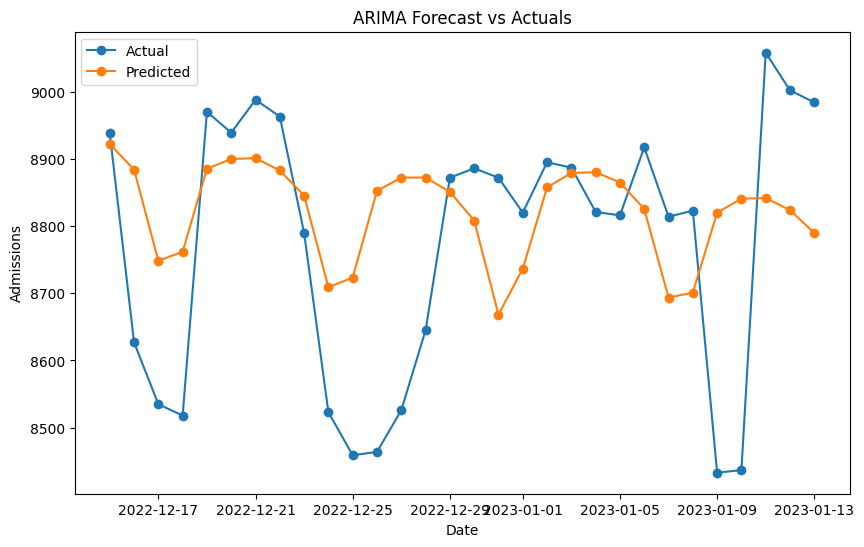

In [ ]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
cv_results = arima_mod.cross_validate(df=train, cv_split=5, test_size=30, metrics=mtrcs, step_size=3, cv_df=True)

# plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(test.index, test["admissions"], label="Actual", marker='o')
plt.plot(test.index, trn, label="Predicted", marker='o')
plt.title("ARIMA Forecast vs Actuals")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.legend()
plt.show()